In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
train_df = pd.read_csv('/content/train_data.csv', on_bad_lines='skip', engine='python')
test_df = pd.read_csv('/content/test_data.csv', on_bad_lines='skip', engine='python')

In [7]:
train_df.columns = train_df.columns.str.replace(r'\\', '', regex=True).str.strip()
test_df.columns = test_df.columns.str.replace(r'\\', '', regex=True).str.strip()

In [8]:
train_df = train_df.dropna()
test_df = test_df.dropna()

In [9]:
le = LabelEncoder()

In [10]:
all_items = pd.concat([train_df['Item'], test_df['Item']]).unique()
le.fit(all_items)

LabelEncoder()

In [11]:
train_df['Item_Encoded'] = le.transform(train_df['Item'])
test_df['Item_Encoded'] = le.transform(test_df['Item'])

In [12]:
features = ['Item_Encoded', 'Year', 'Yield_Lag1', 'Yield_Lag2',
            'Production_Lag1', 'Area_Lag1', 'Yield_RollingMean_3Y',
            'Area_Growth_Lag1', 'Production_Growth_Lag1']

In [13]:
X_train = train_df[features]
y_train = train_df['Yield']

X_test = test_df[features]
y_test = test_df['Yield']

# **Modeling: Decision Tree Regressor**

In [14]:
dt_model = DecisionTreeRegressor(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=5, random_state=42)

In [15]:
y_pred = dt_model.predict(X_test)

# **Model Evaluation**

In [16]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("--- Model Evaluation Metrics ---")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2 Score): {r2:.4f}")

--- Model Evaluation Metrics ---
Mean Absolute Error (MAE): 1362.16
Mean Squared Error (MSE): 7808757.55
Root Mean Squared Error (RMSE): 2794.42
R-squared (R2 Score): 0.9708


# **Error Analysis**

## **1. Building the Errors Table**

---



In [17]:
err_df = test_df[['Item', 'Year']].copy()
err_df['Actual'] = y_test.values
err_df['Predicted'] = y_pred
err_df['Error'] = err_df['Predicted'] - err_df['Actual']        # + over-prediction, - under-prediction
err_df['Abs_Error'] = err_df['Error'].abs()
err_df['Pct_Error'] = (err_df['Abs_Error'] / err_df['Actual'].replace(0, np.nan)) * 100

# Baseline: repeat last year's yield
err_df['Baseline_Pred'] = test_df['Yield_Lag1'].values
err_df['Baseline_Abs_Error'] = (err_df['Baseline_Pred'] - err_df['Actual']).abs()

print(f"Mean Error (Bias): {err_df['Error'].mean():.2f}")
print(f"Median Abs Error : {err_df['Abs_Error'].median():.2f}")
print(f"Mean Abs Error   : {err_df['Abs_Error'].mean():.2f}")
print(f"Median % Error   : {err_df['Pct_Error'].median():.2f}%")
print(f"90th pct Abs Err : {err_df['Abs_Error'].quantile(0.90):.2f}")
print(f"Max Abs Error    : {err_df['Abs_Error'].max():.2f}")
err_df.head()

Mean Error (Bias): 95.20
Median Abs Error : 709.37
Mean Abs Error   : 1362.16
Median % Error   : 7.84%
90th pct Abs Err : 2923.69
Max Abs Error    : 40978.30


,Item,Year,Actual,Predicted,Error,Abs_Error,Pct_Error,Baseline_Pred,Baseline_Abs_Error
0,"Anise, badian, coriander, cumin, caraway, fenn...",2014,881.4,1567.284925,685.884925,685.884925,77.817668,885.6,4.2
1,"Anise, badian, coriander, cumin, caraway, fenn...",2015,884.9,1567.284925,682.384925,682.384925,77.114355,881.4,3.5
2,"Anise, badian, coriander, cumin, caraway, fenn...",2016,887.1,1567.284925,680.184925,680.184925,76.675113,884.9,2.2
3,"Anise, badian, coriander, cumin, caraway, fenn...",2017,890.7,1567.284925,676.584925,676.584925,75.961033,887.1,3.6
4,"Anise, badian, coriander, cumin, caraway, fenn...",2018,893.1,1567.284925,674.184925,674.184925,75.488179,890.7,2.4


## **2. Residual Diagnostics**

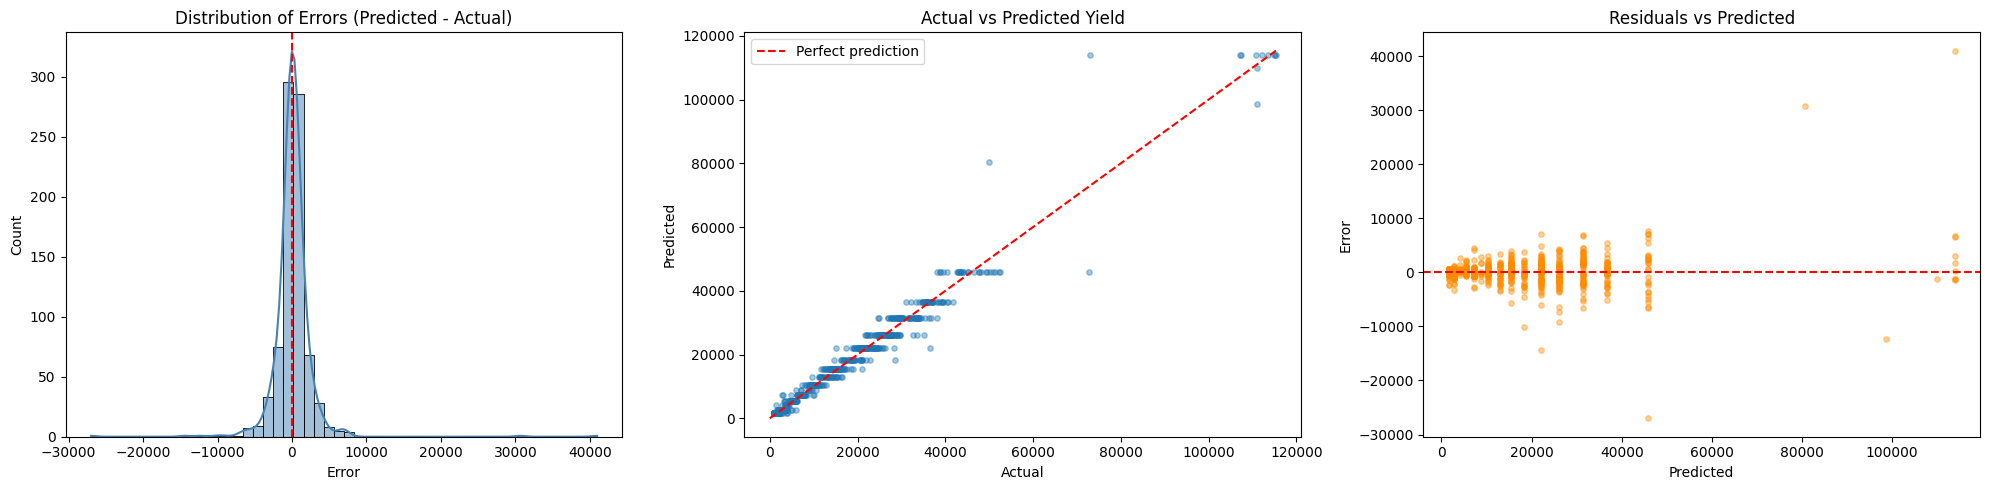

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# (a) Distribution of errors
sns.histplot(err_df['Error'], bins=50, kde=True, ax=axes[0], color='steelblue')
axes[0].axvline(0, color='red', linestyle='--')
axes[0].set_title('Distribution of Errors (Predicted - Actual)')
axes[0].set_xlabel('Error')

# (b) Actual vs Predicted
axes[1].scatter(err_df['Actual'], err_df['Predicted'], alpha=0.4, s=15)
lims = [0, max(err_df['Actual'].max(), err_df['Predicted'].max())]
axes[1].plot(lims, lims, 'r--', label='Perfect prediction')
axes[1].set_title('Actual vs Predicted Yield')
axes[1].set_xlabel('Actual'); axes[1].set_ylabel('Predicted')
axes[1].legend()

# (c) Residuals vs Predicted
axes[2].scatter(err_df['Predicted'], err_df['Error'], alpha=0.4, s=15, color='darkorange')
axes[2].axhline(0, color='red', linestyle='--')
axes[2].set_title('Residuals vs Predicted')
axes[2].set_xlabel('Predicted'); axes[2].set_ylabel('Error')

plt.tight_layout()
plt.show()

## **3. Error by Crop (Item)**

In [19]:
item_err = err_df.groupby('Item').agg(
    Count=('Error', 'size'),
    Mean_Actual=('Actual', 'mean'),
    MAE=('Abs_Error', 'mean'),
    RMSE=('Error', lambda x: np.sqrt((x**2).mean())),
    Bias=('Error', 'mean'),
    Median_Pct_Error=('Pct_Error', 'median'),
    Baseline_MAE=('Baseline_Abs_Error', 'mean'),
).round(2)

item_err['MAE_vs_MeanYield_%'] = (item_err['MAE'] / item_err['Mean_Actual'] * 100).round(2)
item_err['Beats_Baseline'] = item_err['MAE'] < item_err['Baseline_MAE']
item_err = item_err.sort_values('MAE', ascending=False)

print("Top 15 crops by MAE:")
display(item_err.head(15))

print(f"\nCrops where the tree beats the baseline: {item_err['Beats_Baseline'].sum()} / {len(item_err)}")

Top 15 crops by MAE:


,Count,Mean_Actual,MAE,RMSE,Bias,Median_Pct_Error,Baseline_MAE,MAE_vs_MeanYield_%,Beats_Baseline
Item,,,,,,,,,
Sugar beet,11,52207.55,8811.75,13014.09,-3236.22,9.82,5459.83,16.88,False
Sugar cane,11,108328.25,6971.81,13274.06,3780.72,1.46,8328.13,6.44,True
Tomatoes,11,40482.43,4039.96,4358.14,1162.01,7.52,1248.78,9.98,False
Sweet potatoes,11,33937.49,3161.77,4019.78,-2463.63,7.17,2150.26,9.32,False
Dates,11,29572.67,2939.72,3429.41,1988.32,8.83,2170.95,9.94,False
"Onions and shallots, dry (excluding dehydrated)",11,35892.94,2781.59,4839.28,-1502.26,3.18,1893.28,7.75,False
Cauliflowers and broccoli,11,27882.08,2769.63,3131.02,-177.02,7.44,1604.71,9.93,False
Bananas,11,43165.50,2501.68,3220.16,979.77,4.12,2067.82,5.80,False
Eggplants (aubergines),11,28122.04,2311.15,3002.88,-58.90,5.80,1734.63,8.22,False



Crops where the tree beats the baseline: 5 / 77


/tmp/ipykernel_880/3528185631.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='MAE', y='Item', data=top_items, ax=axes[0], palette='Reds_r')
/tmp/ipykernel_880/3528185631.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Bias', y='Item', data=top_items, ax=axes[1], palette='coolwarm')


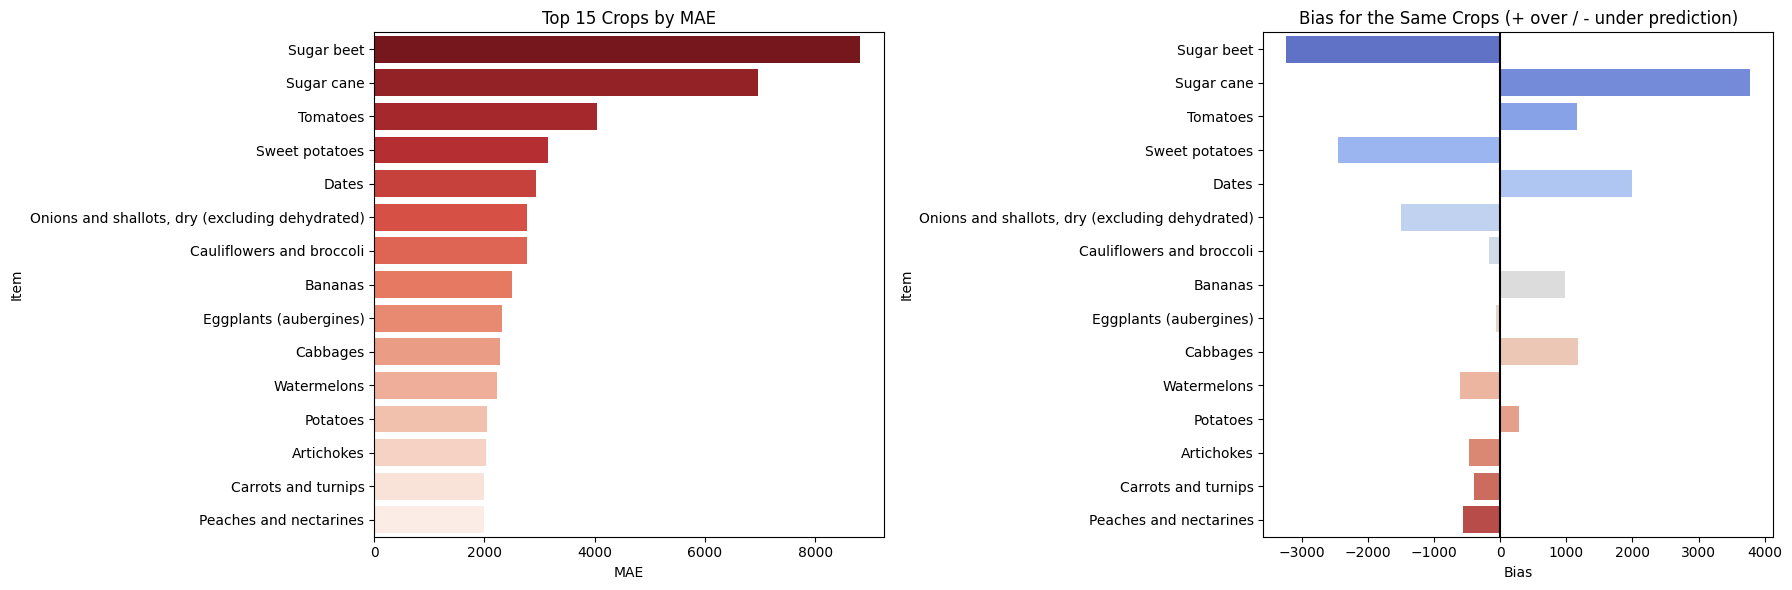

In [20]:
top_items = item_err.head(15).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.barplot(x='MAE', y='Item', data=top_items, ax=axes[0], palette='Reds_r')
axes[0].set_title('Top 15 Crops by MAE')

sns.barplot(x='Bias', y='Item', data=top_items, ax=axes[1], palette='coolwarm')
axes[1].axvline(0, color='black')
axes[1].set_title('Bias for the Same Crops (+ over / - under prediction)')

plt.tight_layout()
plt.show()

## **4. Share of Total Error per Crop**


In [21]:
sq = err_df.assign(Sq_Error=err_df['Error']**2).groupby('Item')['Sq_Error'].sum()
share = (sq / sq.sum() * 100).sort_values(ascending=False)

print("Share of total squared error (top 10 crops):")
print(share.head(10).round(2).to_string())
print(f"\nTop 5 crops account for {share.head(5).sum():.1f}% of the total squared error")

Share of total squared error (top 10 crops):
Item
Sugar cane                                         30.01
Sugar beet                                         28.85
Onions and shallots, dry (excluding dehydrated)     3.99
Tomatoes                                            3.24
Sweet potatoes                                      2.75
Dates                                               2.00
Artichokes                                          1.96
Bananas                                             1.77
Cauliflowers and broccoli                           1.67
Eggplants (aubergines)                              1.54

Top 5 crops account for 68.8% of the total squared error


## **5. Error over Time**

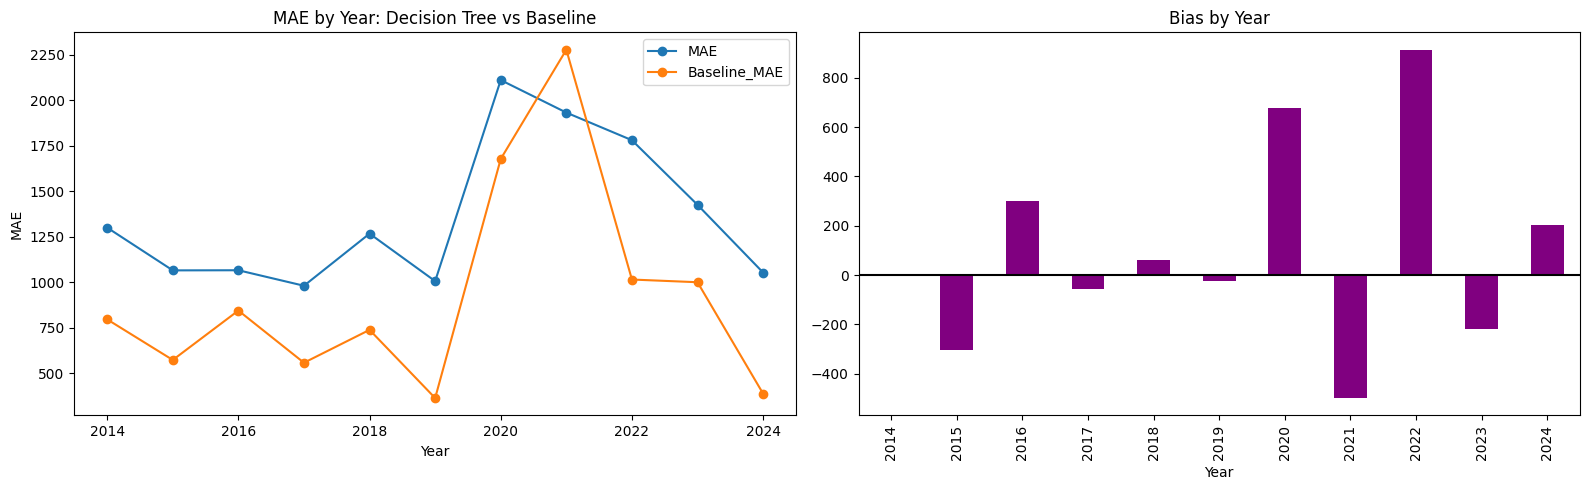

,MAE,Baseline_MAE,Bias
Year,,,
2014,1300.04,795.53,-3.43
2015,1065.12,572.46,-303.24
2016,1065.80,844.16,300.00
2017,980.56,557.19,-58.32
2018,1267.16,737.99,61.55
2019,1006.02,363.01,-22.54
2020,2111.62,1677.93,675.52
2021,1932.75,2278.38,-498.70
2022,1781.01,1014.78,913.51


In [22]:
year_err = err_df.groupby('Year').agg(
    MAE=('Abs_Error', 'mean'),
    Baseline_MAE=('Baseline_Abs_Error', 'mean'),
    Bias=('Error', 'mean'),
).round(2)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

year_err[['MAE', 'Baseline_MAE']].plot(marker='o', ax=axes[0])
axes[0].set_title('MAE by Year: Decision Tree vs Baseline')
axes[0].set_ylabel('MAE')

year_err['Bias'].plot(kind='bar', ax=axes[1], color='purple')
axes[1].axhline(0, color='black')
axes[1].set_title('Bias by Year')

plt.tight_layout()
plt.show()
display(year_err)

## **6. Worst Predictions**

In [23]:
worst = err_df.sort_values('Abs_Error', ascending=False).head(15)
display(worst[['Item', 'Year', 'Actual', 'Predicted', 'Error', 'Pct_Error', 'Baseline_Pred']].round(2))

,Item,Year,Actual,Predicted,Error,Pct_Error,Baseline_Pred
723,Sugar cane,2020,72879.7,113858.00,40978.30,56.23,110877.1
714,Sugar beet,2022,49894.2,80559.60,30665.40,61.46,49482.6
712,Sugar beet,2020,72814.8,45812.50,-27002.30,37.08,48158.8
397,"Onions and shallots, dry (excluding dehydrated)",2014,36579.0,22162.40,-14416.60,39.41,20737.3
724,Sugar cane,2021,110938.6,98604.53,-12334.07,11.12,72879.7
40,Artichokes,2021,28523.9,18369.21,-10154.69,35.60,18791.5
746,Sweet potatoes,2021,35227.2,26101.20,-9126.00,25.91,27656.7
52,Bananas,2021,38177.3,45812.50,7635.20,20.00,43257.7
228,Eggplants (aubergines),2021,33457.9,26101.20,-7356.70,21.99,27262.7
260,Grapes,2020,15040.3,22162.40,7122.10,47.35,22000.0


## **7. Error by Yield Level**


,Count,MAE,Bias,Median_Pct_Error
Yield_Bin,,,,
"(871.899, 3146.42]",166,450.65,167.51,17.94
"(3146.42, 7543.84]",165,683.33,26.19,11.37
"(7543.84, 15730.96]",165,979.69,239.13,7.10
"(15730.96, 26832.18]",165,1501.27,203.32,5.43
"(26832.18, 115355.2]",166,3190.32,-159.03,6.13


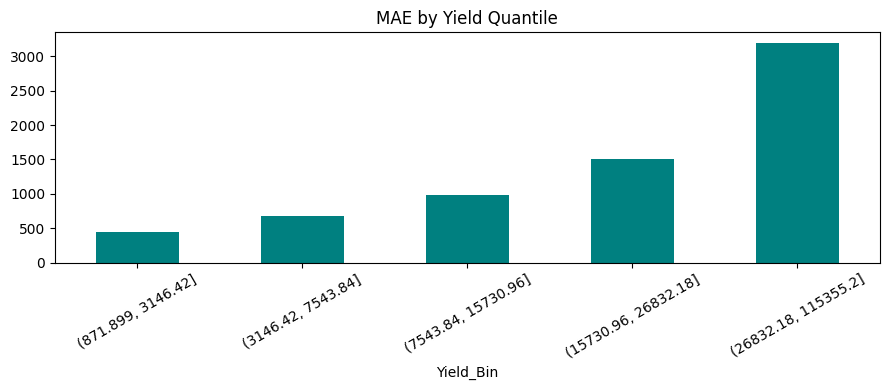

In [24]:
err_df['Yield_Bin'] = pd.qcut(err_df['Actual'], q=5, duplicates='drop')

bin_err = err_df.groupby('Yield_Bin', observed=True).agg(
    Count=('Error', 'size'),
    MAE=('Abs_Error', 'mean'),
    Bias=('Error', 'mean'),
    Median_Pct_Error=('Pct_Error', 'median'),
).round(2)
display(bin_err)

bin_err['MAE'].plot(kind='bar', figsize=(9, 4), color='teal')
plt.title('MAE by Yield Quantile')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# **Model Interpretation & Feature Importance**

In [25]:
feature_importances = dt_model.feature_importances_
importance_df = pd.DataFrame({'Feature': features, 'Importance': feature_importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

/tmp/ipykernel_880/2192983652.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')


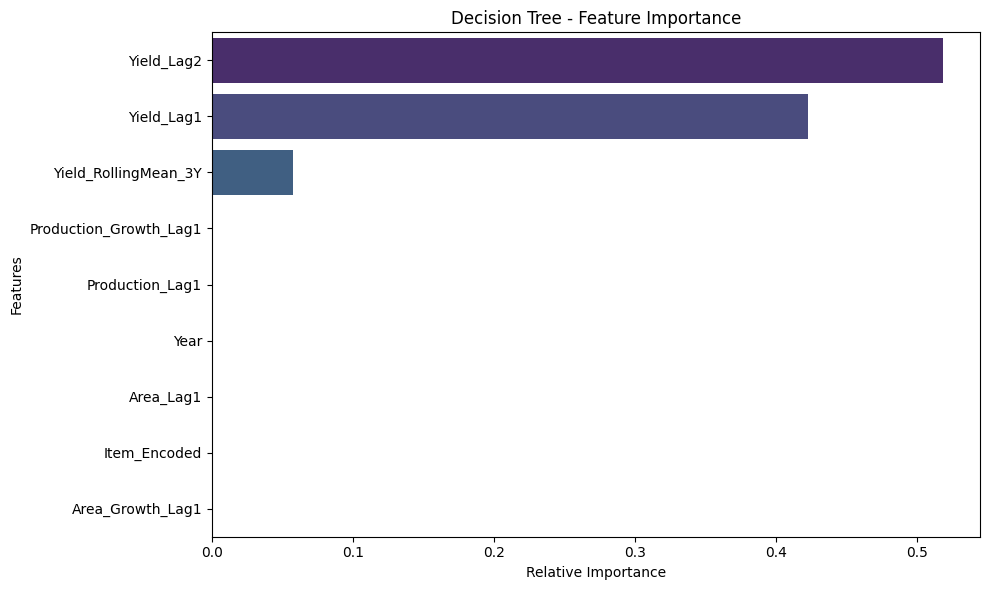

In [26]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title('Decision Tree - Feature Importance')
plt.xlabel('Relative Importance')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

# **Decision Tree Structure**

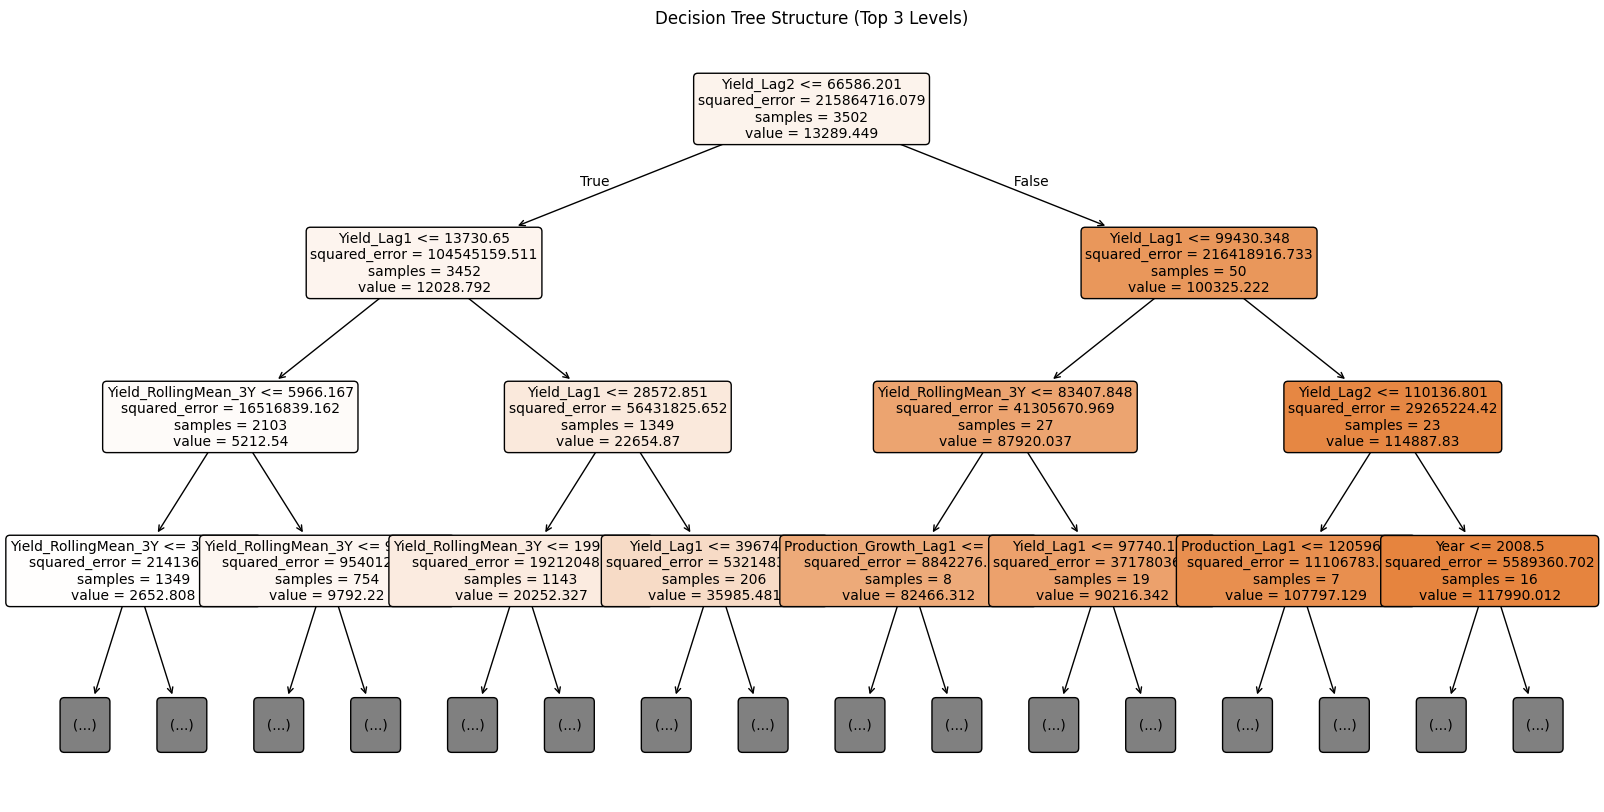

In [27]:
plt.figure(figsize=(20, 10))
plot_tree(dt_model, feature_names=features, filled=True, rounded=True, fontsize=10, max_depth=3)
plt.title('Decision Tree Structure (Top 3 Levels)')
plt.show()

# **Models Comparison**

## **Models Performance:**


The metrics demonstrate a clear superiority of the Linear Regression model over the Decision Tree in predicting crop yields. The Linear Regression achieved an R^2 of 0.979 on the test data, whereas the Decision Tree's accuracy dropped to 0.9708.

The interesting paradox appears when comparing the errors against the simple "Baseline Model" (which merely repeats the previous year's yield). This baseline model achieved the lowest Mean Absolute Error (MAE) at 929.05, but the Linear Regression succeeded in significantly reducing the Root Mean Squared Error (RMSE) to 2370 compared to 2671 for the baseline. In contrast, the Decision Tree recorded the highest error rates across the board (MAE = 1362.16 and RMSE = 2794.42).

### **Reasons for Differences & Strengths/Weaknesses:**

* Linear Regression:

  - Strengths: Excellent at capturing continuous linear relationships. Its ability to comprehend the fundamental differences between crops was crucial; it recognized that crops like Sugar cane and Sugar beet have a massive base yield, assigning them high positive coefficients to adjust the prediction. It also logically focused on the previous year's yield Yield_Lag1 and the rolling average Yield_RollingMean_3Y as the most important numerical indicators.   
  - Weaknesses: It may struggle if complex climatic features with non-linear relationships (like the impact of extreme temperatures) are introduced.
* Decision Tree:
  - Strengths: Easy to interpret and trace the decision-making path at each node based on numerical conditions.   
  - Weaknesses: The nature of the tree relies on splitting data into fixed bins (leaves) and assigning a constant mean value to each bin, which is a weak approach for handling numerical time series with continuous growth. Furthermore, the model completely ignored the crop type (Item_Encoded importance is close to zero), relying almost entirely on Yield_Lag2, which explains the high variance in its errors.   